   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.1/888.1 MB 712.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

100%|██████████| 94.3M/94.3M [00:02<00:00, 38.3MB/s]


[INFO] EuroSAT downloaded to: /content/data  | Images: 27000 | Binary classes: ['Non-Infrastructure', 'Infrastructure']


,binary_class,label_id,count
0,Non-Infrastructure,0,19000
1,Infrastructure,1,8000


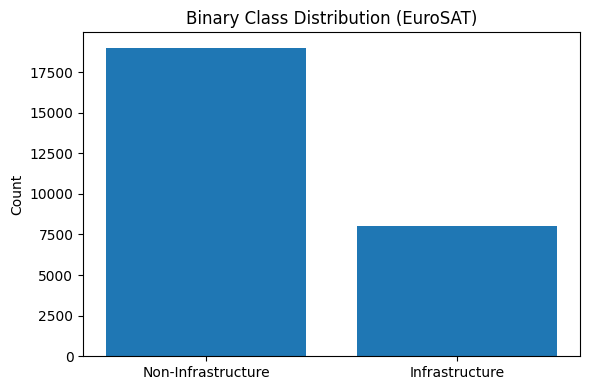

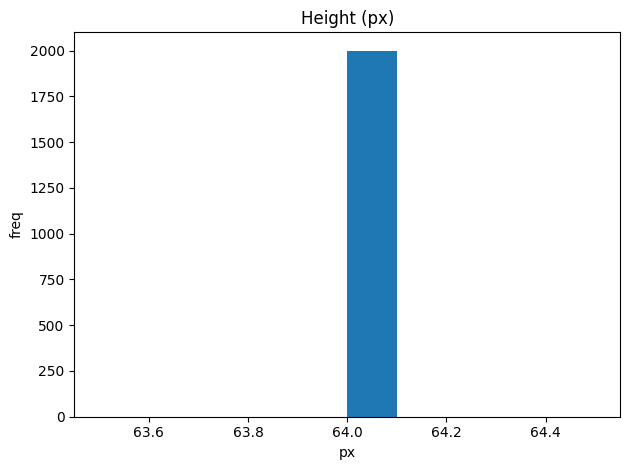

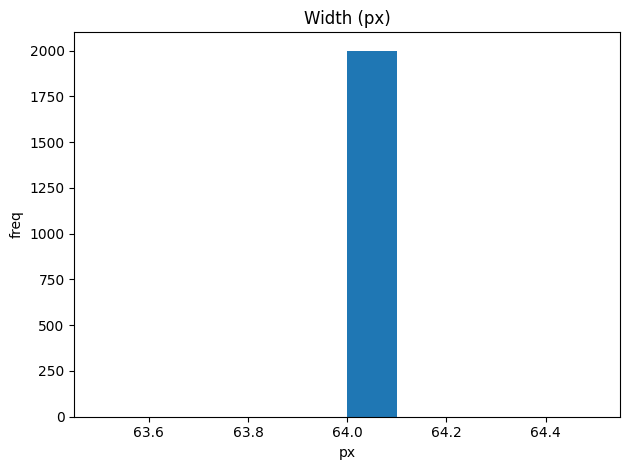

,channel,mean,std
0,R,0.344376,0.202661
1,G,0.380291,0.136897
2,B,0.407770,0.115550


,binary_class,channel,mean,std
0,Non-Infrastructure,R,0.318333,0.199104
1,Non-Infrastructure,G,0.361551,0.126717
2,Non-Infrastructure,B,0.386812,0.098384
3,Infrastructure,R,0.406229,0.197557
4,Infrastructure,G,0.424799,0.149328
5,Infrastructure,B,0.457547,0.136209


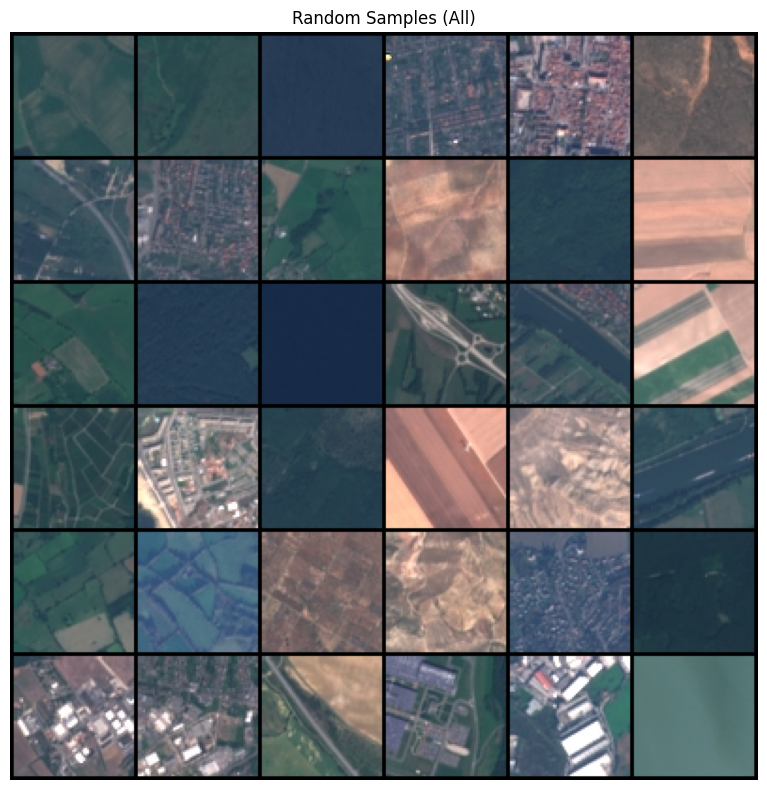

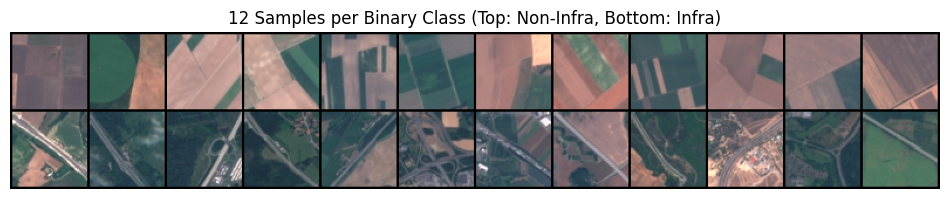

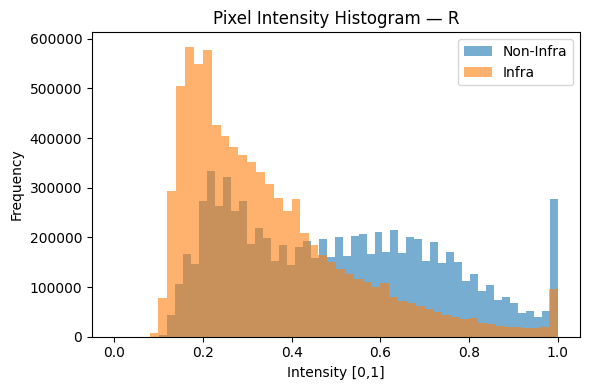

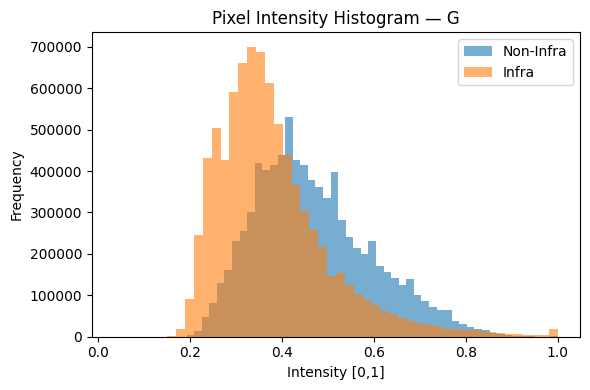

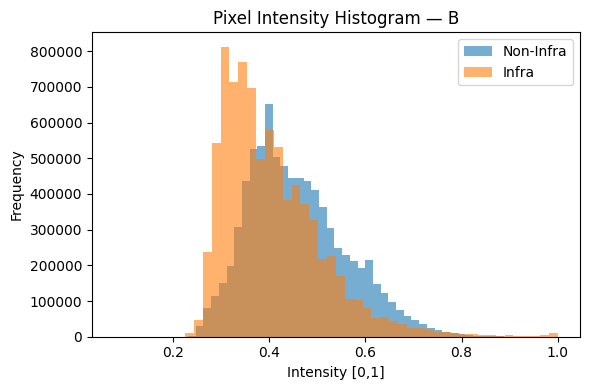

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 45.1MB/s]


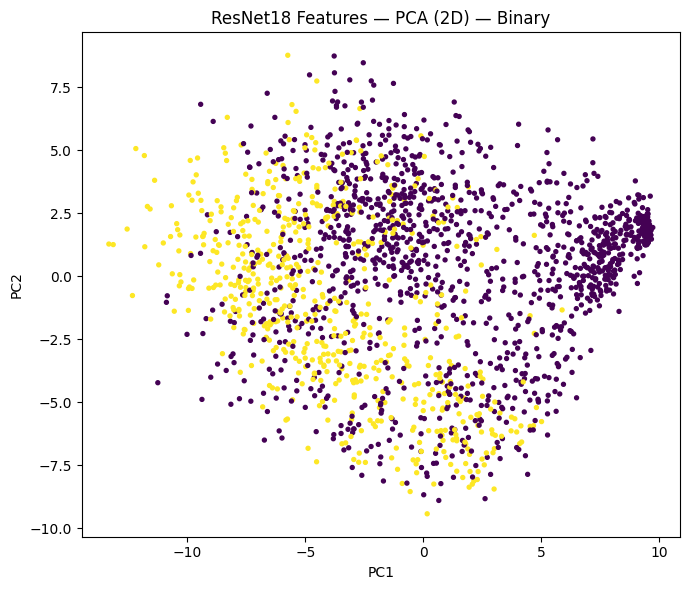

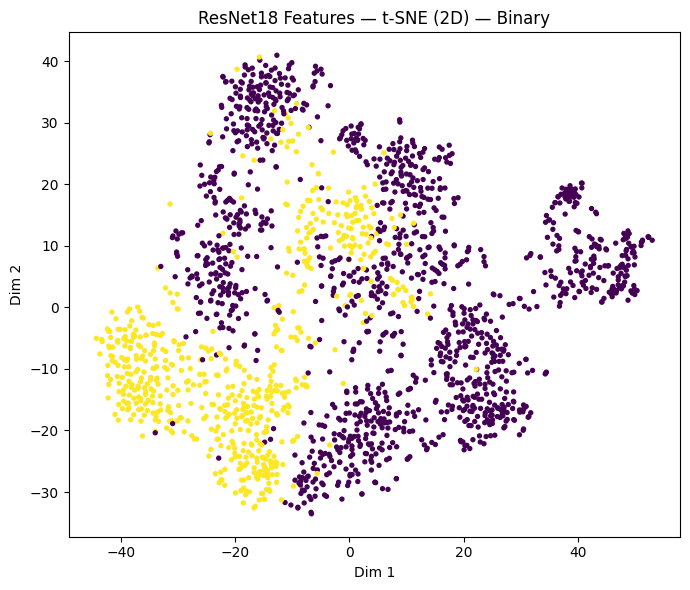


[DONE] Outputs saved in: /content/eda_out
total 1744
drwxr-xr-x 2 root root   4096 Aug 11 16:57 .
drwxr-xr-x 1 root root   4096 Aug 11 16:54 ..
-rw-r--r-- 1 root root     77 Aug 11 16:54 binary_class_counts.csv
-rw-r--r-- 1 root root  43266 Aug 11 16:54 binary_class_distribution.png
-rw-r--r-- 1 root root    379 Aug 11 16:54 channel_stats_by_binary_class.csv
-rw-r--r-- 1 root root    141 Aug 11 16:54 channel_stats_overall.csv
-rw-r--r-- 1 root root  35180 Aug 11 16:54 height_hist.png
-rw-r--r-- 1 root root  53446 Aug 11 16:55 hist_B_by_binary.png
-rw-r--r-- 1 root root  51154 Aug 11 16:55 hist_G_by_binary.png
-rw-r--r-- 1 root root  48621 Aug 11 16:55 hist_R_by_binary.png
-rw-r--r-- 1 root root     18 Aug 11 16:54 image_sizes_counts.csv
-rw-r--r-- 1 root root 362629 Aug 11 16:57 pca_2d_binary.png
-rw-r--r-- 1 root root 310013 Aug 11 16:54 per_binary_class_grid.png
-rw-r--r-- 1 root root     63 Aug 11 16:54 pixel_range_sampled.csv
-rw-r--r-- 1 root root 427467 Aug 11 16:54 random_grid_

In [1]:

MODE = "download"  
DATA_DIR = "/content/drive/MyDrive/EuroSAT"
OUT_DIR = "eda_out"
SEED = 42

# Install & Imports
!pip -q install torch torchvision --upgrade
import os, random, math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, utils, models
from torchvision.datasets.folder import default_loader

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)

# Binary mapping
INFRA_CLASSES = {"Residential", "Highway", "Industrial"}  # -> label 1
# all others -> label 0

def build_label_map(class_names):
    is_infra = np.array([1 if (cn in INFRA_CLASSES) else 0 for cn in class_names])
    return is_infra 

class BinaryMapDataset(Dataset):
    """
    Wraps a (image, class_id) dataset and remaps class_id -> binary_label (0 non-infra, 1 infra)
    """
    def __init__(self, base_ds, class_names):
        self.base = base_ds
        self.class_names = class_names
        self.map_arr = build_label_map(class_names)
       
        if hasattr(base_ds, "samples"):
            self.samples = base_ds.samples
        elif hasattr(base_ds, "imgs"):
            self.samples = base_ds.imgs
        else:
            self.samples = None

    @property
    def classes(self):
        return ["Non-Infrastructure", "Infrastructure"]

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]        # y is original 0..9
        y_bin = int(self.map_arr[y])
        return x, y_bin

# DATA LOADING
if MODE.lower() == "download":
    DATA_ROOT = "/content/data"
    base_ds = datasets.EuroSAT(root=DATA_ROOT, download=True, transform=transforms.ToTensor())
    class_names = base_ds.classes
    ds = BinaryMapDataset(base_ds, class_names)
    print(f"[INFO] EuroSAT downloaded to: {DATA_ROOT}  | Images: {len(ds)} | Binary classes: {ds.classes}")
elif MODE.lower() == "drive":
    from google.colab import drive
    drive.mount('/content/drive')
    assert os.path.isdir(DATA_DIR), f"[ERROR] DATA_DIR not found: {DATA_DIR}"
    print("[INFO] Listing classes at:", DATA_DIR)
    !ls -la "$DATA_DIR" | head -n 50

    base_ds = datasets.ImageFolder(root=DATA_DIR, transform=transforms.ToTensor())
    class_names = base_ds.classes
    ds = BinaryMapDataset(base_ds, class_names)
    print(f"[INFO] Loaded from Drive | Images: {len(ds)} | Binary classes: {ds.classes}")
else:
    raise ValueError("MODE must be 'download' or 'drive'.")

# Binary Class Distribution

if hasattr(base_ds, "samples"):
    orig_labels = [y for _, y in base_ds.samples]
elif hasattr(base_ds, "targets"):
    orig_labels = list(base_ds.targets)
else:
    orig_labels = [base_ds[i][1] for i in range(len(base_ds))]

map_arr = build_label_map(class_names)
binary_labels = [int(map_arr[y]) for y in orig_labels]
cnt = Counter(binary_labels)

df_counts = pd.DataFrame({
    "binary_class": ["Non-Infrastructure", "Infrastructure"],
    "label_id": [0, 1],
    "count": [cnt.get(0,0), cnt.get(1,0)]
})
display(df_counts)
df_counts.to_csv(os.path.join(OUT_DIR, "binary_class_counts.csv"), index=False)

plt.figure(figsize=(6,4))
plt.bar(df_counts["binary_class"], df_counts["count"])
plt.title("Binary Class Distribution (EuroSAT)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "binary_class_distribution.png"), dpi=200)
plt.show()

# Image Characteristics (resolution, overall channel stats, pixel range)

sample_idxs = random.sample(range(len(ds)), k=min(2000, len(ds)))
heights, widths, px_min, px_max = [], [], [], []
for i in sample_idxs:
    x, _ = ds[i]  
    h, w = x.shape[1], x.shape[2]
    heights.append(h); widths.append(w)
    px_min.append(float(x.min())); px_max.append(float(x.max()))

pd.Series([f"{w}x{h}" for w,h in zip(widths, heights)]).value_counts().sort_index() \
  .to_csv(os.path.join(OUT_DIR, "image_sizes_counts.csv"))

plt.figure(); plt.hist(heights, bins=10); plt.title("Height (px)"); plt.xlabel("px"); plt.ylabel("freq")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "height_hist.png"), dpi=200); plt.show()

plt.figure(); plt.hist(widths, bins=10); plt.title("Width (px)"); plt.xlabel("px"); plt.ylabel("freq")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "width_hist.png"), dpi=200); plt.show()

# Overall channel stats
loader = DataLoader(ds, batch_size=256, shuffle=True, num_workers=2)
n_pixels = 0
sum_ch = torch.zeros(3)
sqsum_ch = torch.zeros(3)

n_pix_bin = torch.zeros(2)
sum_bin = torch.zeros(2, 3)
sqsum_bin = torch.zeros(2, 3)

for xb, yb in loader:
    # xb: [B,C,H,W], yb: [B]
    b, c, h, w = xb.shape
    n = b*h*w
    sum_ch   += xb.sum(dim=[0,2,3])
    sqsum_ch += (xb**2).sum(dim=[0,2,3])
    n_pixels += n

    # per binary class
    for label in (0, 1):
        mask = (yb == label)
        if mask.any():
            xk = xb[mask]                   
            n_k = xk.shape[0]*h*w
            sum_bin[label]   += xk.sum(dim=[0,2,3])
            sqsum_bin[label] += (xk**2).sum(dim=[0,2,3])
            n_pix_bin[label] += n_k

mean = sum_ch / n_pixels
std  = torch.sqrt(sqsum_ch / n_pixels - mean**2)

stats_overall = pd.DataFrame({"channel": ["R","G","B"], "mean": mean.tolist(), "std": std.tolist()})
display(stats_overall)
stats_overall.to_csv(os.path.join(OUT_DIR, "channel_stats_overall.csv"), index=False)

# Per binary class stats
per_class_rows = []
for label, name in enumerate(["Non-Infrastructure", "Infrastructure"]):
    if n_pix_bin[label] > 0:
        m = sum_bin[label] / n_pix_bin[label]
        s = torch.sqrt(sqsum_bin[label] / n_pix_bin[label] - m**2)
        per_class_rows.append({"binary_class": name, "channel": "R", "mean": m[0].item(), "std": s[0].item()})
        per_class_rows.append({"binary_class": name, "channel": "G", "mean": m[1].item(), "std": s[1].item()})
        per_class_rows.append({"binary_class": name, "channel": "B", "mean": m[2].item(), "std": s[2].item()})
df_stats_bin = pd.DataFrame(per_class_rows)
display(df_stats_bin)
df_stats_bin.to_csv(os.path.join(OUT_DIR, "channel_stats_by_binary_class.csv"), index=False)

pd.Series({"pixel_min_sampled": np.min(px_min), "pixel_max_sampled": np.max(px_max)}).to_csv(
    os.path.join(OUT_DIR, "pixel_range_sampled.csv")
)

# Visual Exploration (random grid, k samples per binary class)
def show_random_grid(dataset, n=36, fname="random_grid.png"):
    idxs = random.sample(range(len(dataset)), n)
    imgs = [dataset[i][0] for i in idxs]
    grid = utils.make_grid(imgs, nrow=int(math.sqrt(n)))
    plt.figure(figsize=(8,8)); plt.imshow(grid.permute(1,2,0)); plt.axis("off")
    plt.title("Random Samples (All)"); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=200); plt.show()

show_random_grid(ds, n=36, fname="random_grid_all.png")

def show_per_binary_class(dataset, k=24, fname="per_binary_class.png"):
    buckets = {0: [], 1: []}
    for idx in range(len(dataset)):
        _, yb = dataset[idx]
        if len(buckets[yb]) < k:
            buckets[yb].append(idx)
        if len(buckets[0]) == k and len(buckets[1]) == k:
            break
    imgs = []
    titles = []
    for label, name in [(0,"Non-Infrastructure"), (1,"Infrastructure")]:
        for idx in buckets[label]:
            imgs.append(dataset[idx][0])
            titles.append(name)
    nrow = k
    grid = utils.make_grid(imgs, nrow=k, padding=2)
    plt.figure(figsize=(k*0.8, 5))
    plt.imshow(grid.permute(1,2,0)); plt.axis("off")
    plt.title(f"{k} Samples per Binary Class (Top: Non-Infra, Bottom: Infra)" if k>1 else "Per Binary Class")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, fname), dpi=300); plt.show()

show_per_binary_class(ds, k=12, fname="per_binary_class_grid.png")

# Pixel Intensity Histograms per binary class

def pixel_histograms_by_binary(dataset, per_class_samples=2500):
    idxs_0, idxs_1 = [], []
    # stratified sampling
    for i in range(len(dataset)):
        _, yb = dataset[i]
        if yb == 0 and len(idxs_0) < per_class_samples:
            idxs_0.append(i)
        elif yb == 1 and len(idxs_1) < per_class_samples:
            idxs_1.append(i)
        if len(idxs_0) == per_class_samples and len(idxs_1) == per_class_samples:
            break

    def gather_vals(idxs):
        vals = []
        for i in idxs:
            x, _ = dataset[i]
            vals.append(x.view(3, -1).numpy())
        return np.concatenate(vals, axis=1) if len(vals)>0 else np.zeros((3,0))

    v0 = gather_vals(idxs_0)
    v1 = gather_vals(idxs_1)

    for ch, name in enumerate(["R","G","B"]):
        plt.figure(figsize=(6,4))
        if v0.shape[1] > 0:
            plt.hist(v0[ch], bins=50, alpha=0.6, label="Non-Infra")
        if v1.shape[1] > 0:
            plt.hist(v1[ch], bins=50, alpha=0.6, label="Infra")
        plt.title(f"Pixel Intensity Histogram — {name}")
        plt.xlabel("Intensity [0,1]"); plt.ylabel("Frequency"); plt.legend()
        plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, f"hist_{name}_by_binary.png"), dpi=200); plt.show()

pixel_histograms_by_binary(ds, per_class_samples=2000)

# Feature Space Analysis (ResNet18 embeddings) — PCA & t-SNE (binary colors)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = torch.nn.Identity()
resnet = resnet.to(DEVICE).eval()

feat_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

if hasattr(base_ds, "samples"):         
    samples_list = base_ds.samples
elif hasattr(base_ds, "imgs"):
    samples_list = base_ds.imgs
elif hasattr(base_ds, "_image_files"):
    samples_list = list(zip(base_ds._image_files, base_ds._labels))
else:
    raise RuntimeError("Cannot access file paths. Upgrade torchvision or use MODE='drive'.")

# Sample N images and map to binary labels
N = min(2000, len(samples_list))
embed_samples = random.sample(samples_list, k=N)

class EmbedSet(Dataset):
    def __init__(self, samples, transform, class_names):
        self.samples = samples           
        self.transform = transform
        self.class_names = class_names
        self.map_arr = build_label_map(class_names)
        self.targets = [int(self.map_arr[y]) for _, y in samples]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, y_orig = self.samples[i]
        img = default_loader(path)  # PIL
        img = self.transform(img)
        y_bin = int(self.map_arr[y_orig])
        return img, y_bin

embed_ds = EmbedSet(embed_samples, feat_tfms, class_names)
embed_loader = DataLoader(embed_ds, batch_size=128, shuffle=False, num_workers=2)

feats, labs_bin = [], []
with torch.no_grad():
    for xb, yb in embed_loader:
        xb = xb.to(DEVICE)
        f = resnet(xb).cpu().numpy()
        feats.append(f); labs_bin.append(yb.numpy())
feats = np.concatenate(feats); labs_bin = np.concatenate(labs_bin)

# PCA (2D)
pca = PCA(n_components=2, random_state=SEED)
p2 = pca.fit_transform(feats)
plt.figure(figsize=(7,6))
plt.scatter(p2[:,0], p2[:,1], s=8, c=labs_bin)
plt.title("ResNet18 Features — PCA (2D) — Binary")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "pca_2d_binary.png"), dpi=200); plt.show()

# t-SNE (2D)
ts = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=SEED)
t2 = ts.fit_transform(feats)
plt.figure(figsize=(7,6))
plt.scatter(t2[:,0], t2[:,1], s=8, c=labs_bin)
plt.title("ResNet18 Features — t-SNE (2D) — Binary")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "tsne_2d_binary.png"), dpi=200); plt.show()

# Save Summary CSVs
summary_counts = df_counts.copy()
summary_counts.to_csv(os.path.join(OUT_DIR, "summary_binary_counts.csv"), index=False)
stats_overall.to_csv(os.path.join(OUT_DIR, "summary_channel_stats_overall.csv"), index=False)
df_stats_bin.to_csv(os.path.join(OUT_DIR, "summary_channel_stats_by_binary_class.csv"), index=False)

print("\n[DONE] Outputs saved in:", os.path.abspath(OUT_DIR))
!ls -la "$OUT_DIR" | head -n 50
